# Actividad 2 · Calidad, drift y anomalías
**Análisis de Datos II · 4B2026**

En esta actividad analicé la calidad del dataset de salarios, comparé sus distribuciones entre dos períodos y busqué registros atípicos con Isolation Forest y LOF. Utilicé el mismo archivo `ds_salaries.csv` de la Actividad 1.

Implementé los chequeos y PSI explícitamente con pandas y NumPy para mostrar las reglas, los intervalos y las contribuciones. Para las anomalías seguí el preprocesamiento y los estimadores de scikit-learn usados en clase.

In [1]:
from pathlib import Path
import sys
import hashlib
import warnings
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

SEED = 42
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'datasets/ds_salaries.csv').exists())
DATA = ROOT / 'datasets/ds_salaries.csv'
df = pd.read_csv(DATA)
VARIABLES = ['salary_in_usd', 'experience_level', 'remote_ratio', 'company_size']
DOMINIOS = {'experience_level': ['EN', 'MI', 'SE', 'EX'],
            'remote_ratio': [0, 50, 100], 'company_size': ['S', 'M', 'L']}
plt.rcParams.update({'figure.figsize': (9, 5), 'axes.grid': True, 'grid.alpha': 0.2})
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print('Python:', sys.version.split()[0], '| Intérprete:', sys.executable)
print({p: metadata.version(p) for p in ['numpy', 'pandas', 'scikit-learn', 'matplotlib']})
print('SHA256:', hashlib.sha256(DATA.read_bytes()).hexdigest())
print('Dimensiones:', df.shape)
display(df.head())

Python: 3.12.13 | Intérprete: /Users/gabrielper12/Projects/Analisis_datos_ii_tareas/.venv/bin/python
{'numpy': '1.26.4', 'pandas': '2.3.3', 'scikit-learn': '1.9.1', 'matplotlib': '3.11.2'}
SHA256: b156e54135634169cedc91c685851450d890a05f0753a2a655895e2475e946e6
Dimensiones: (3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## 1. Preparación de los períodos
Separé **referencia: 2020–2021** y **actual: 2022–2023**, sin muestreo aleatorio. Elegí estas cuatro variables:

| Variable | Motivo de mi elección | Papel en el modelo de salarios |
|---|---|---|
| `salary_in_usd` | Comparo salarios en una moneda común y reviso la distribución del objetivo. | Target Y |
| `experience_level` | Representa el nivel de experiencia; fue relevante en el modelo corregido de la Actividad 1. | Entrada X |
| `remote_ratio` | Describe la modalidad de trabajo: 0 presencial, 50 híbrida y 100 remota. | Entrada X |
| `company_size` | Describe el contexto de la empresa: S, M y L. | Entrada X |

Para PSI traté `remote_ratio` como una variable discreta con tres categorías. Para medir distancias en anomalías usé su porcentaje numérico, asumiendo que la diferencia entre 0 y 50 es comparable con la de 50 a 100. No incorporé `salary` para evitar mezclar monedas y duplicar la información del salario.

Mantuve inicialmente todas las filas: la frecuencia de cada perfil forma parte de las distribuciones observadas. Más adelante muestro una sensibilidad de PSI sin duplicados exactos.

In [2]:
assert df.work_year.isin([2020, 2021, 2022, 2023]).all()
referencia = df.loc[df.work_year.isin([2020, 2021])].copy()
actual = df.loc[df.work_year.isin([2022, 2023])].copy()
assert len(referencia) + len(actual) == len(df)
assert referencia.index.intersection(actual.index).empty
periodos = {'Referencia 2020–2021': referencia, 'Actual 2022–2023': actual}
display(df.groupby('work_year').size().rename('registros').to_frame())
display(pd.DataFrame({nombre: {
    'n': len(d), 'salario medio USD': d.salary_in_usd.mean(),
    'salario mediano USD': d.salary_in_usd.median(),
    'duplicados exactos adicionales': int(d.duplicated().sum())
} for nombre, d in periodos.items()}).T)
display(Markdown(f'Comparé **{len(referencia)}** registros de referencia con **{len(actual)}** actuales. '
    'Usé proporciones para que la diferencia de tamaños no se confunda con un cambio de distribución. '
    'Aun así, reconozco que la referencia pequeña hace más incierta la estimación de sus frecuencias.'))

,registros
work_year,
2020,76
2021,230
2022,1664
2023,1785


,n,salario medio USD,salario mediano USD,duplicados exactos adicionales
Referencia 2020–2021,306.0000,"93,643.9804","79,833.0000",3.0000
Actual 2022–2023,"3,449.0000","141,467.6010","138,750.0000","1,168.0000"


Comparé **306** registros de referencia con **3449** actuales. Usé proporciones para que la diferencia de tamaños no se confunda con un cambio de distribución. Aun así, reconozco que la referencia pequeña hace más incierta la estimación de sus frecuencias.

## 2. Calidad: reglas y resultados
Definí las reglas antes de interpretar el drift. Para cada variable y período revisé **completitud**, **tipo/formato** y **validez de valores**. Agregué una revisión de **unicidad de filas completas**.

- Para completitud exigí ausencia de nulos y cadenas vacías.
- Para tipo/formato exigí números en salario y porcentaje remoto, y texto en experiencia y tamaño.
- Para validez exigí salario finito y positivo; experiencia en EN/MI/SE/EX; remoto en 0/50/100; tamaño en S/M/L. No fijé un máximo salarial arbitrario: un sueldo alto puede ser válido.
- Para unicidad marqué las repeticiones completas para revisión. No consideré error que dos personas compartieran solamente estas cuatro variables.

Los tres primeros controles admiten cero incumplimientos. La alerta de duplicados requiere investigar la procedencia: sin un identificador de persona o contrato no puedo afirmar que cada repetición sea un error.

In [3]:
chequeos = []
for periodo, datos in periodos.items():
    for variable in VARIABLES:
        s = datos[variable]
        no_vacio = s.notna() & s.astype('string').str.strip().ne('').fillna(False)
        if variable in ['salary_in_usd', 'remote_ratio']:
            tipo_ok = s.map(lambda v: isinstance(v, (int, float, np.number)) and not isinstance(v, (bool, np.bool_)))
        else:
            tipo_ok = s.map(lambda v: isinstance(v, str))
        if variable == 'salary_in_usd':
            valores = pd.to_numeric(s, errors='coerce')
            valido = np.isfinite(valores) & (valores > 0)
        else:
            valido = s.isin(DOMINIOS[variable])
        for regla, mascara in [('Completitud', no_vacio), ('Tipo/formato', tipo_ok), ('Validez', valido)]:
            fallos = int((~mascara).sum())
            chequeos.append([periodo, variable, regla, len(datos), fallos, 100 * fallos / len(datos),
                             'OK' if fallos == 0 else 'REVISAR'])
    fallos = int(datos.duplicated().sum())
    chequeos.append([periodo, 'Fila completa', 'Unicidad', len(datos), fallos,
                     100 * fallos / len(datos), 'OK' if fallos == 0 else 'REVISAR'])
calidad = pd.DataFrame(chequeos, columns=['período', 'variable', 'chequeo', 'n', 'incumplimientos', '%', 'estado'])
display(calidad)
assert calidad.loc[calidad.chequeo != 'Unicidad', 'incumplimientos'].sum() == 0, 'Revisar valores inválidos antes de continuar.'
display(Markdown(f'No encontré nulos, problemas de formato ni valores fuera de los dominios definidos en las cuatro variables. '
    f'Sí encontré **{df.duplicated().sum()} filas duplicadas adicionales** en el dataset. '
    'Las mantuve en el análisis principal y contrasté luego PSI sin ellas. Pasar estos controles no me permite garantizar '
    'exactitud del salario ni oportunidad de llegada: no tengo una fuente externa ni fechas de ingreso para verificarlas.'))

,período,variable,chequeo,n,incumplimientos,%,estado
0,Referencia 2020–2021,salary_in_usd,Completitud,306,0,0.0000,OK
1,Referencia 2020–2021,salary_in_usd,Tipo/formato,306,0,0.0000,OK
2,Referencia 2020–2021,salary_in_usd,Validez,306,0,0.0000,OK
3,Referencia 2020–2021,experience_level,Completitud,306,0,0.0000,OK
4,Referencia 2020–2021,experience_level,Tipo/formato,306,0,0.0000,OK
5,Referencia 2020–2021,experience_level,Validez,306,0,0.0000,OK
6,Referencia 2020–2021,remote_ratio,Completitud,306,0,0.0000,OK
7,Referencia 2020–2021,remote_ratio,Tipo/formato,306,0,0.0000,OK
8,Referencia 2020–2021,remote_ratio,Validez,306,0,0.0000,OK
9,Referencia 2020–2021,company_size,Completitud,306,0,0.0000,OK


No encontré nulos, problemas de formato ni valores fuera de los dominios definidos en las cuatro variables. Sí encontré **1171 filas duplicadas adicionales** en el dataset. Las mantuve en el análisis principal y contrasté luego PSI sin ellas. Pasar estos controles no me permite garantizar exactitud del salario ni oportunidad de llegada: no tengo una fuente externa ni fechas de ingreso para verificarlas.

## 3. Drift: cálculo e interpretación de PSI
Usé la definición de la clase 3:

$$PSI = \sum_i (q_i-p_i)\ln\left(\frac{q_i}{p_i}\right)$$

Aquí $p_i$ es la proporción de referencia y $q_i$ la actual. Apliqué la convención de la diapositiva 33:

| PSI | Mi decisión |
|---|---|
| Menor que 0,10 | No detecto una señal relevante con este criterio. |
| Mayor o igual a 0,10 y menor que 0,25 | Detecto cambio moderado y activo seguimiento. |
| Mayor o igual a 0,25 | Detecto cambio fuerte y activo una alerta de revisión del modelo. |

Fijé **0,25 como umbral principal de alerta**, y 0,10 como advertencia. Son umbrales operativos, no p-valores ni pruebas de significación estadística.

Para salario usé diez intervalos definidos por los deciles de **referencia**; extendí los extremos a menos y más infinito para incluir salarios actuales fuera del rango histórico. Para las variables discretas usé las mismas categorías en ambos períodos. Reemplacé proporciones menores que $10^{-6}$ por ese valor y renormalicé para evitar logaritmos de cero. Muestro tanto las proporciones originales como las suavizadas, de modo que el cálculo sea auditable.

In [4]:
EPS = 1e-6
UMBRAL = 0.25
limites_salario = np.r_[-np.inf, np.unique(referencia.salary_in_usd.quantile(np.arange(0.1, 1, 0.1))), np.inf]

def tabla_psi(ref, act, variable, limites=None):
    if variable == 'salary_in_usd':
        bordes = limites_salario if limites is None else limites
        r = pd.cut(ref[variable], bins=bordes)
        a = pd.cut(act[variable], bins=bordes)
        soporte = r.cat.categories
    else:
        r, a = ref[variable], act[variable]
        soporte = DOMINIOS[variable]
        assert r.isin(soporte).all() and a.isin(soporte).all()
    nr = r.value_counts().reindex(soporte, fill_value=0).astype(int)
    na = a.value_counts().reindex(soporte, fill_value=0).astype(int)
    assert nr.sum() == len(ref) and na.sum() == len(act)
    p, q = nr / nr.sum(), na / na.sum()
    ps, qs = p.clip(lower=EPS), q.clip(lower=EPS)
    ps, qs = ps / ps.sum(), qs / qs.sum()
    t = pd.DataFrame({'n_ref': nr, 'n_actual': na, 'p_ref': p, 'q_actual': q,
                      'p_suavizada': ps, 'q_suavizada': qs,
                      'aporte_PSI': (qs - ps) * np.log(qs / ps)})
    t.index.name = 'intervalo / categoría'
    assert np.isfinite(t.aporte_PSI).all()
    return t

def nivel_psi(valor):
    return 'Fuerte: alerta' if valor >= UMBRAL else ('Moderado: seguimiento' if valor >= 0.10 else 'Sin señal relevante')

tablas_psi = {v: tabla_psi(referencia, actual, v) for v in VARIABLES}
resumen_psi = pd.DataFrame({'PSI': {v: t.aporte_PSI.sum() for v, t in tablas_psi.items()}})
resumen_psi['umbral_alerta'] = UMBRAL
resumen_psi['decisión'] = resumen_psi.PSI.map(nivel_psi)
resumen_psi['tipo compatible'] = ['Cambio marginal del target P(Y)' if v == 'salary_in_usd'
                                else 'Data drift de entrada P(X)' for v in resumen_psi.index]
display(resumen_psi)
for variable, tabla in tablas_psi.items():
    display(Markdown(f'### Detalle de PSI: `{variable}`'))
    display(tabla)
# Compruebo que comparar la referencia consigo misma da PSI cero.
assert all(np.isclose(tabla_psi(referencia, referencia, v).aporte_PSI.sum(), 0) for v in VARIABLES)

,PSI,umbral_alerta,decisión,tipo compatible
salary_in_usd,0.8701,0.2500,Fuerte: alerta,Cambio marginal del target P(Y)
experience_level,0.7417,0.2500,Fuerte: alerta,Data drift de entrada P(X)
remote_ratio,1.1914,0.2500,Fuerte: alerta,Data drift de entrada P(X)
company_size,2.1981,0.2500,Fuerte: alerta,Data drift de entrada P(X)


### Detalle de PSI: `salary_in_usd`

,n_ref,n_actual,p_ref,q_actual,p_suavizada,q_suavizada,aporte_PSI
intervalo / categoría,,,,,,,
"(-inf, 19341.0]",31,39,0.1013,0.0113,0.1013,0.0113,0.1973
"(19341.0, 36643.0]",31,47,0.1013,0.0136,0.1013,0.0136,0.1759
"(36643.0, 50090.0]",30,109,0.0980,0.0316,0.0980,0.0316,0.0752
"(50090.0, 63831.0]",32,138,0.1046,0.0400,0.1046,0.0400,0.0620
"(63831.0, 79833.0]",30,186,0.0980,0.0539,0.0980,0.0539,0.0264
"(79833.0, 93150.0]",30,202,0.0980,0.0586,0.0980,0.0586,0.0203
"(93150.0, 110906.0]",30,382,0.0980,0.1108,0.0980,0.1108,0.0016
"(110906.0, 141846.0]",31,746,0.1013,0.2163,0.1013,0.2163,0.0872
"(141846.0, 185000.0]",31,850,0.1013,0.2464,0.1013,0.2464,0.1290


### Detalle de PSI: `experience_level`

,n_ref,n_actual,p_ref,q_actual,p_suavizada,q_suavizada,aporte_PSI
intervalo / categoría,,,,,,,
EN,78,242,0.2549,0.0702,0.2549,0.0702,0.2383
MI,124,681,0.4052,0.1974,0.4052,0.1974,0.1494
SE,91,2425,0.2974,0.7031,0.2974,0.7031,0.3491
EX,13,101,0.0425,0.0293,0.0425,0.0293,0.0049


### Detalle de PSI: `remote_ratio`

,n_ref,n_actual,p_ref,q_actual,p_suavizada,q_suavizada,aporte_PSI
intervalo / categoría,,,,,,,
0,50,1873,0.1634,0.5431,0.1634,0.5431,0.4560
50,97,92,0.3170,0.0267,0.3170,0.0267,0.7186
100,159,1484,0.5196,0.4303,0.5196,0.4303,0.0169


### Detalle de PSI: `company_size`

,n_ref,n_actual,p_ref,q_actual,p_suavizada,q_suavizada,aporte_PSI
intervalo / categoría,,,,,,,
S,72,76,0.2353,0.0220,0.2353,0.0220,0.5050
M,72,3081,0.2353,0.8933,0.2353,0.8933,0.8778
L,162,292,0.5294,0.0847,0.5294,0.0847,0.8153


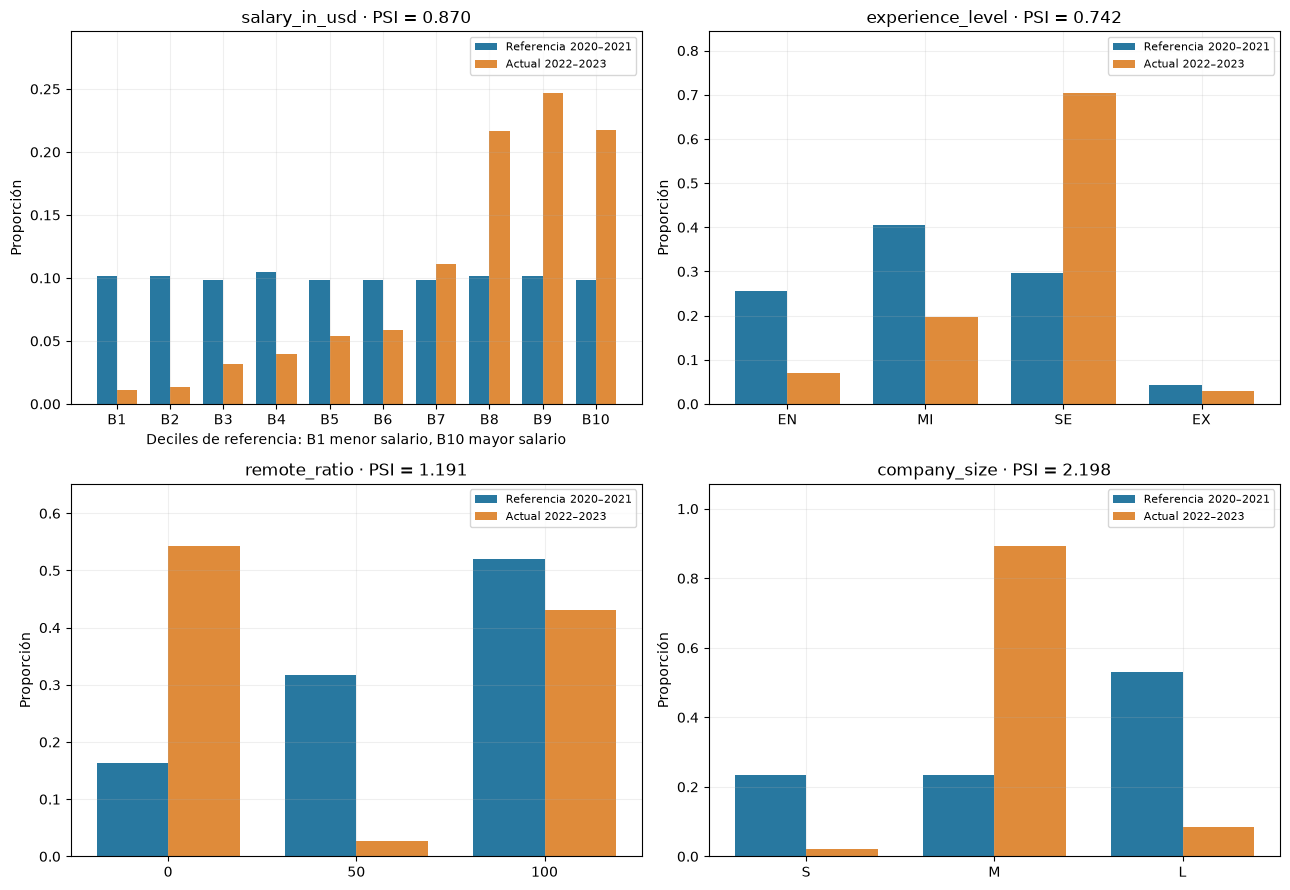

**salary_in_usd:** obtuve PSI = **0.8701**, por encima del umbral de **0.25**. Mi decisión es **Fuerte: alerta**. El mayor aporte proviene de **(-inf, 19341.0]**, cuya proporción pasa de **10.1%** a **1.1%**.

**experience_level:** obtuve PSI = **0.7417**, por encima del umbral de **0.25**. Mi decisión es **Fuerte: alerta**. El mayor aporte proviene de **SE**, cuya proporción pasa de **29.7%** a **70.3%**.

**remote_ratio:** obtuve PSI = **1.1914**, por encima del umbral de **0.25**. Mi decisión es **Fuerte: alerta**. El mayor aporte proviene de **50**, cuya proporción pasa de **31.7%** a **2.7%**.

**company_size:** obtuve PSI = **2.1981**, por encima del umbral de **0.25**. Mi decisión es **Fuerte: alerta**. El mayor aporte proviene de **M**, cuya proporción pasa de **23.5%** a **89.3%**.

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (variable, tabla) in zip(axes.flat, tablas_psi.items()):
    x = np.arange(len(tabla))
    ax.bar(x - .19, tabla.p_ref, .38, label='Referencia 2020–2021', color='#2878a0')
    ax.bar(x + .19, tabla.q_actual, .38, label='Actual 2022–2023', color='#df8b3a')
    etiquetas = [f'B{i+1}' for i in x] if variable == 'salary_in_usd' else tabla.index.astype(str)
    ax.set_xticks(x, etiquetas)
    ax.set(title=f'{variable} · PSI = {resumen_psi.loc[variable, "PSI"]:.3f}', ylabel='Proporción')
    if variable == 'salary_in_usd':
        ax.set_xlabel('Deciles de referencia: B1 menor salario, B10 mayor salario')
    ax.set_ylim(0, max(tabla.p_ref.max(), tabla.q_actual.max()) * 1.2)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for variable in VARIABLES:
    valor = resumen_psi.loc[variable, 'PSI']
    t = tablas_psi[variable]
    principal = t.aporte_PSI.idxmax()
    display(Markdown(f'**{variable}:** obtuve PSI = **{valor:.4f}**, '
        f'{"por encima" if valor >= UMBRAL else "por debajo"} del umbral de **{UMBRAL:.2f}**. '
        f'Mi decisión es **{nivel_psi(valor)}**. El mayor aporte proviene de **{principal}**, '
        f'cuya proporción pasa de **{t.loc[principal, "p_ref"]:.1%}** a **{t.loc[principal, "q_actual"]:.1%}**.'))

### Qué tipo de drift puedo sostener
La mediana salarial pasó de **79.833 a 138.750 USD**. También observé un aumento de perfiles SE, de **29,7 % a 70,3 %**, y de empresas M, de **23,5 % a 89,3 %**. En modalidad de trabajo, la proporción presencial aumentó de **16,3 % a 54,3 %** y la híbrida bajó de **31,7 % a 2,7 %**. Estos cambios me ayudan a interpretar los PSI; no puedo atribuir el aumento salarial a una única variable ni asumir que refleja aumentos para las mismas personas.

Interpreto los cambios de experiencia, modalidad remota y tamaño de empresa como **data drift en las entradas**. Son compatibles con covariate shift, pero no puedo asegurar con PSI que la relación $P(Y|X)$ haya permanecido igual.

En `salary_in_usd` analizo un cambio en la distribución marginal del target, $P(Y)$. Lo describo como **target drift**; no afirmo que sea un caso puro de label shift, porque no comprobé la estabilidad de $P(X|Y)$.

Tampoco concluyo que haya **concept drift**: para sostener un cambio en $P(Y|X)$ necesitaría analizar la relación condicional y el desempeño temporal del modelo. PSI compara distribuciones marginales y no demuestra por sí solo deterioro predictivo ni una causa económica. Una explicación posible es un cambio en la composición de la muestra de empleos o en la forma de recopilarlos.

### Sensibilidad del diagnóstico
Para revisar cuánto depende mi conclusión de decisiones de cálculo, repetí PSI salarial con 5 y 20 intervalos definidos en referencia. También recalculé PSI de las cuatro variables después de quitar filas completas idénticas dentro de cada período, manteniendo los intervalos originales. No usé este segundo análisis para afirmar que las repeticiones sean errores; lo usé para evaluar su influencia.

In [6]:
sens_bins = []
for b in [5, 10, 20]:
    bordes = np.r_[-np.inf, np.unique(referencia.salary_in_usd.quantile(np.arange(1, b) / b)), np.inf]
    valor = tabla_psi(referencia, actual, 'salary_in_usd', bordes).aporte_PSI.sum()
    sens_bins.append({'intervalos': len(bordes)-1, 'PSI salario': valor, 'decisión': nivel_psi(valor)})
display(pd.DataFrame(sens_bins))
ref_unicos, act_unicos = referencia.drop_duplicates(), actual.drop_duplicates()
sens_duplicados = resumen_psi[['PSI']].rename(columns={'PSI': 'PSI todas las filas'}).copy()
sens_duplicados['PSI sin duplicados exactos'] = [tabla_psi(ref_unicos, act_unicos, v).aporte_PSI.sum() for v in VARIABLES]
sens_duplicados['decisión sin duplicados'] = sens_duplicados['PSI sin duplicados exactos'].map(nivel_psi)
display(sens_duplicados)
print(f'Sin duplicados: {len(ref_unicos)} filas de referencia y {len(act_unicos)} actuales.')
alertas_robustas = (sens_duplicados['PSI sin duplicados exactos'] >= UMBRAL).sum()
display(Markdown(f'Al retirar duplicados, **{alertas_robustas} de las 4 variables** siguen superando 0,25. '
    'Interpreto esta comparación junto con la tabla de intervalos; no la considero una validación estadística. '
    'La referencia tiene solo 306 observaciones y mis resultados describen este dataset, no todo el mercado laboral.'))

,intervalos,PSI salario,decisión
0,5,0.8416,Fuerte: alerta
1,10,0.8701,Fuerte: alerta
2,20,0.9650,Fuerte: alerta


,PSI todas las filas,PSI sin duplicados exactos,decisión sin duplicados
salary_in_usd,0.8701,0.6795,Fuerte: alerta
experience_level,0.7417,0.5333,Fuerte: alerta
remote_ratio,1.1914,0.9481,Fuerte: alerta
company_size,2.1981,1.8506,Fuerte: alerta


Sin duplicados: 303 filas de referencia y 2281 actuales.


Al retirar duplicados, **4 de las 4 variables** siguen superando 0,25. Interpreto esta comparación junto con la tabla de intervalos; no la considero una validación estadística. La referencia tiene solo 306 observaciones y mis resultados describen este dataset, no todo el mercado laboral.

## 4. Estrategia para el modelo de la Actividad 1
**Elegiría reentrenamiento con datos recientes y validación temporal.** Tomaría como punto de partida el Random Forest corregido de la Actividad 1, sin `salary`. En ese trabajo obtuve R² = 0,397 y MAE = 36.527 USD con el split aleatorio; el R² de 0,983 del modelo original estaba favorecido por leakage y no lo usaría como referencia de calidad.

Mi elección se apoya en las alertas PSI y en que `experience_level`, una de las entradas que cambió, tenía PFI = 0,181 en el modelo corregido. Al cambiar la composición de los perfiles y el nivel de salarios, considero razonable actualizar el modelo con ejemplos representativos del período reciente. No puedo asumir que ese cambio vaya a mejorar las métricas sin evaluarlo.

Aplicaría este procedimiento:

1. Revisaría la procedencia de duplicados y la cobertura por experiencia, país y empresa. Mantendría fuera `salary` y no usaría `salary_in_usd` como entrada predictiva.
2. Compararía un bosque ajustado con 2020–2021 y un candidato ajustado con datos disponibles hasta 2022, dejando 2023 como evaluación temporal común. Ajustaría los preprocesadores solo con el entrenamiento correspondiente y revisaría repeticiones entre conjuntos. Esta prueba sería retrospectiva; reservaría datos posteriores todavía no analizados para decidir un despliegue real.
3. Compararía MAE, RMSE y R², además del error por experiencia, modalidad y tamaño de empresa. Reemplazaría el modelo solo si el candidato mejora de manera consistente y mantiene cobertura de los subgrupos.
4. Mantendría un monitoreo de calidad, PSI y errores cuando lleguen los salarios reales.

Consideraría **feature engineering** como complemento si identificara un mecanismo concreto, por ejemplo expresar salarios en USD de poder adquisitivo constante con un índice externo verificado. Eso sería una transformación del objetivo que requeriría definir el año base y cómo volver a la escala de evaluación; no lo confundiría con agregar automáticamente una nueva variable de entrada. No lo haría automáticamente a partir de PSI. Un **ensamble** de modelos históricos y recientes podría ayudar si demostrara que existen regímenes recurrentes, pero aquí no tengo esa evidencia y agregaría complejidad.

**Alcance:** propongo esta estrategia, no afirmo haber demostrado una mejora por reentrenamiento. El modelo de la Actividad 1 se entrenó con un split aleatorio que mezcló años; no puedo tratarlo como si hubiera sido entrenado únicamente en 2020–2021 ni evaluar 2022–2023 completos como datos nunca vistos por él.

## 5. Detección de anomalías: preparación y parámetros
Apliqué ambos métodos al dataset completo usando las mismas cuatro variables. En esta etapa **sí incluí `salary_in_usd`**, porque busco salarios y perfiles atípicos en registros ya observados; no estoy entrenando un predictor del salario ni un detector para usar antes de conocerlo.

Estandaricé salario y porcentaje remoto para que las unidades no dominen las distancias de LOF. Codifiqué experiencia y tamaño con one-hot sin escalarlas, evitando imponerles distancias ordinales arbitrarias. Cada bloque categórico aporta una distancia euclídea de $\sqrt{2}$ cuando cambia la categoría. Reconozco que esta elección de representación influye en la vecindad y, por tanto, en las anomalías.

Usé **Isolation Forest con 200 árboles**, semilla 42 y `contamination=0.05`, como en el ejemplo de clase. Para **LOF** revisé primero la multiplicidad de los perfiles: con 20 vecinos, un grupo de observaciones idénticas puede ocupar toda la vecindad y producir densidades problemáticas. Comparé esa configuración con 50 vecinos y conservé **k = 50**, mayor que la multiplicidad máxima observada. Después revisé k = 75 y 100 como sensibilidad.

Elegí el 5 % como presupuesto exploratorio de revisión, no como una tasa real conocida de errores. Las cantidades marcadas pueden diferir ligeramente del 5 % por empates en los scores. Ajusté y evalué sobre las mismas filas porque esta es una detección descriptiva no supervisada; no reporto estas etiquetas como desempeño en datos nuevos.

Distingo las **filas completas duplicadas** de los **perfiles iguales en las cuatro variables**: estos últimos pueden corresponder a registros diferentes en año, país o puesto. La multiplicidad máxima de 38 se refiere a esos perfiles. Elegir k=50 evita que toda la vecindad esté formada únicamente por copias idénticas del punto, pero no elimina la influencia de las repeticiones ni garantiza que haya elegido el mejor k. Por eso mantengo el análisis de sensibilidad y considero las etiquetas como alertas para revisión.

Además, al ajustar los detectores con los 3.755 registros juntos, los 3.449 del período actual tienen mayor peso en la distribución de referencia de las anomalías. Mis etiquetas describen rareza respecto de esa mezcla temporal, no necesariamente rareza dentro de cada año. Para monitoreo futuro ajustaría el detector con un período histórico y definiría cómo evaluar observaciones nuevas; aquí utilicé LOF en modo de detección sobre los datos de ajuste.

In [7]:
prep_anomalias = ColumnTransformer([
    ('num', StandardScaler(), ['salary_in_usd', 'remote_ratio']),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['experience_level', 'company_size'])
])
Z = prep_anomalias.fit_transform(df[VARIABLES])
multiplicidad = df.groupby(VARIABLES, dropna=False).size()
print('Máxima cantidad de filas con el mismo perfil de cuatro variables:', int(multiplicidad.max()))

# Reviso el problema de las vecindades con valores repetidos antes de interpretar LOF.
with warnings.catch_warnings(record=True) as advertencias:
    warnings.simplefilter('always')
    lof_20 = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
    lof_20.fit_predict(Z)
print('Advertencias con k=20:', [str(w.message) for w in advertencias])
print('Mayor factor LOF positivo con k=20:', float((-lof_20.negative_outlier_factor_).max()))

K = 50
assert K > multiplicidad.max()
iforest = IsolationForest(n_estimators=200, contamination=0.05, random_state=SEED)
lof = LocalOutlierFactor(n_neighbors=K, contamination=0.05)
resultado = df.copy()
resultado['anomalia_IF'] = iforest.fit_predict(Z) == -1
resultado['score_IF'] = iforest.decision_function(Z)
resultado['anomalia_LOF'] = lof.fit_predict(Z) == -1
resultado['factor_LOF'] = -lof.negative_outlier_factor_
UMBRAL_LOF = -lof.offset_
assert np.isfinite(resultado[['score_IF', 'factor_LOF']]).all().all()
print('IF: marco anomalía cuando decision_function < 0.')
print(f'LOF: marco anomalía cuando factor_LOF > {UMBRAL_LOF:.6f}.')
display(pd.DataFrame({
    'método': ['Isolation Forest', 'LOF (k=50)'],
    'anomalías': [resultado.anomalia_IF.sum(), resultado.anomalia_LOF.sum()],
    '% del dataset': [100 * resultado.anomalia_IF.mean(), 100 * resultado.anomalia_LOF.mean()]
}))
cruce = pd.crosstab(resultado.anomalia_IF, resultado.anomalia_LOF).reindex(index=[False, True], columns=[False, True], fill_value=0)
cruce.index = ['IF: no marcado', 'IF: anomalía']
cruce.columns = ['LOF: no marcado', 'LOF: anomalía']
display(cruce)
interseccion = (resultado.anomalia_IF & resultado.anomalia_LOF).sum()
union = (resultado.anomalia_IF | resultado.anomalia_LOF).sum()
print(f'Coincidencia sobre la unión (Jaccard): {interseccion / union:.3f} ({interseccion}/{union})')
display(Markdown(f'Encontré **{interseccion} registros marcados por ambos métodos**. '
    'No interpreto el resto de los desacuerdos como errores de uno de ellos: Isolation Forest busca puntos '
    'que se aíslan con pocas particiones, mientras que LOF compara densidad local con la de los vecinos. '
    'El control con k=20 también me muestra que los perfiles repetidos pueden distorsionar fuertemente los scores de LOF.'))

Máxima cantidad de filas con el mismo perfil de cuatro variables: 38
Advertencias con k=20: ['Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.']
Mayor factor LOF positivo con k=20: 514630672.38907003
IF: marco anomalía cuando decision_function < 0.
LOF: marco anomalía cuando factor_LOF > 2.555579.


,método,anomalías,% del dataset
0,Isolation Forest,183,4.8735
1,LOF (k=50),187,4.9800


,LOF: no marcado,LOF: anomalía
IF: no marcado,3411,161
IF: anomalía,157,26


Coincidencia sobre la unión (Jaccard): 0.076 (26/344)


Encontré **26 registros marcados por ambos métodos**. No interpreto el resto de los desacuerdos como errores de uno de ellos: Isolation Forest busca puntos que se aíslan con pocas particiones, mientras que LOF compara densidad local con la de los vecinos. El control con k=20 también me muestra que los perfiles repetidos pueden distorsionar fuertemente los scores de LOF.

## 6. Un registro concreto y su interpretación
Para elegir un caso con una regla reproducible, tomé **el salario más alto entre los registros marcados por Isolation Forest**. No elegí el registro buscando que ambos métodos coincidieran. Muestro todas sus columnas originales, sus scores y las decisiones.

Para distinguir una anomalía univariada de una exclusivamente multivariada, comparé su salario con los límites de Tukey: $Q_1-1,5\,IQR$ y $Q_3+1,5\,IQR$. Esta regla es descriptiva: no equivale a un chequeo de validez ni demuestra que el salario sea incorrecto.

Mi clasificación univariada no implica que el salario sea la única causa del score de Isolation Forest: ese detector utiliza las cuatro variables y no calculé una atribución de su score. La regla IQR me permite sostener que el salario del caso es extremo por sí solo. El límite inferior de −25.000 USD que obtuve con esa regla tampoco autoriza salarios negativos: el chequeo de calidad sigue exigiendo un monto positivo.

In [8]:
caso_id = resultado.loc[resultado.anomalia_IF, 'salary_in_usd'].idxmax()
caso = resultado.loc[caso_id]
display(df.loc[[caso_id]].T.rename(columns={caso_id: f'Fila original {caso_id}'}))
display(resultado.loc[[caso_id], ['score_IF', 'anomalia_IF', 'factor_LOF', 'anomalia_LOF']])
q1, q3 = df.salary_in_usd.quantile([0.25, 0.75])
iqr = q3 - q1
inferior, superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
control_uni = pd.DataFrame({'Q1 USD': [q1], 'Q3 USD': [q3], 'IQR USD': [iqr],
    'límite inferior USD': [inferior], 'límite superior USD': [superior],
    'salario del caso USD': [caso.salary_in_usd],
    'outlier por IQR': [caso.salary_in_usd < inferior or caso.salary_in_usd > superior]})
display(control_uni)
assert control_uni['outlier por IQR'].iloc[0]
frecuencias_caso = pd.DataFrame([
    {'variable': v, 'valor del caso': caso[v], 'frecuencia global': df[v].eq(caso[v]).mean()}
    for v in ['experience_level', 'remote_ratio', 'company_size']
])
display(frecuencias_caso)
# Recupero los vecinos usados por LOF, excluyendo automáticamente el propio registro.
distancias, vecinos = lof.kneighbors()
posicion_caso = df.index.get_loc(caso_id)
ids_vecinos = df.index[vecinos[posicion_caso]]
vecinos_caso = resultado.loc[ids_vecinos, VARIABLES + ['factor_LOF']].copy()
vecinos_caso['distancia estandarizada'] = distancias[posicion_caso]
display(vecinos_caso.head(8))
print('Rango salarial entre los 50 vecinos:', vecinos_caso.salary_in_usd.min(), vecinos_caso.salary_in_usd.max())
display(Markdown(f'Identifiqué la **fila {caso_id}**, correspondiente a **{caso.job_title}**, '
    f'año **{caso.work_year}**, experiencia **{caso.experience_level}**, empresa **{caso.company_size}** y '
    f'**{caso.remote_ratio}%** remoto. Su salario es **{caso.salary_in_usd:,.0f} USD**, superior al límite '
    f'univariado de **{superior:,.0f} USD**. Por eso lo clasifico como **outlier univariado salarial**, '
    'aunque lo haya detectado con un método que utiliza varias variables. No necesito una combinación multivariada '
    'para justificar que el monto es extremo.'))
display(Markdown(f'Isolation Forest lo marca con score **{caso.score_IF:.6f} < 0**. '
    f'LOF obtiene un factor de **{caso.factor_LOF:.6f}**, frente al umbral **{UMBRAL_LOF:.6f}**; '
    f'por lo tanto, **{"también lo marca" if caso.anomalia_LOF else "no lo marca con k=50 y contaminación 5%"}**. '
    'Un factor LOF mayor que 1 indica menor densidad local relativa, pero no basta para superar el corte elegido. '
    'Interpreto la discrepancia a partir de esa comparación: ser extremo globalmente no obliga a quedar '
    'entre los scores locales que superan el umbral. Los vecinos mostrados permiten revisar el contexto real del caso.'))

,Fila original 528
work_year,2023
experience_level,SE
employment_type,FT
job_title,AI Scientist
salary,1500000
salary_currency,ILS
salary_in_usd,423834
employee_residence,IL
remote_ratio,0
company_location,IL


,score_IF,anomalia_IF,factor_LOF,anomalia_LOF
528,-0.0226,True,2.4553,False


,Q1 USD,Q3 USD,IQR USD,límite inferior USD,límite superior USD,salario del caso USD,outlier por IQR
0,"95,000.0000","175,000.0000","80,000.0000","-25,000.0000","295,000.0000",423834,True


,variable,valor del caso,frecuencia global
0,experience_level,SE,0.6700
1,remote_ratio,0,0.5121
2,company_size,L,0.1209


,salary_in_usd,experience_level,remote_ratio,company_size,factor_LOF,distancia estandarizada
1421,350000,SE,0,L,2.1024,1.1711
2359,375000,SE,50,L,2.0186,1.2881
133,342300,SE,0,L,1.9941,1.2932
1288,385000,SE,0,M,2.3507,1.5425
1105,370000,SE,0,M,2.5752,1.6520
1311,370000,SE,0,M,2.5752,1.6520
3747,423000,MI,50,L,2.0620,1.7491
68,309400,SE,0,L,1.6352,1.8151


Rango salarial entre los 50 vecinos: 260000 450000


Identifiqué la **fila 528**, correspondiente a **AI Scientist**, año **2023**, experiencia **SE**, empresa **L** y **0%** remoto. Su salario es **423,834 USD**, superior al límite univariado de **295,000 USD**. Por eso lo clasifico como **outlier univariado salarial**, aunque lo haya detectado con un método que utiliza varias variables. No necesito una combinación multivariada para justificar que el monto es extremo.

Isolation Forest lo marca con score **-0.022551 < 0**. LOF obtiene un factor de **2.455300**, frente al umbral **2.555579**; por lo tanto, **no lo marca con k=50 y contaminación 5%**. Un factor LOF mayor que 1 indica menor densidad local relativa, pero no basta para superar el corte elegido. Interpreto la discrepancia a partir de esa comparación: ser extremo globalmente no obliga a quedar entre los scores locales que superan el umbral. Los vecinos mostrados permiten revisar el contexto real del caso.

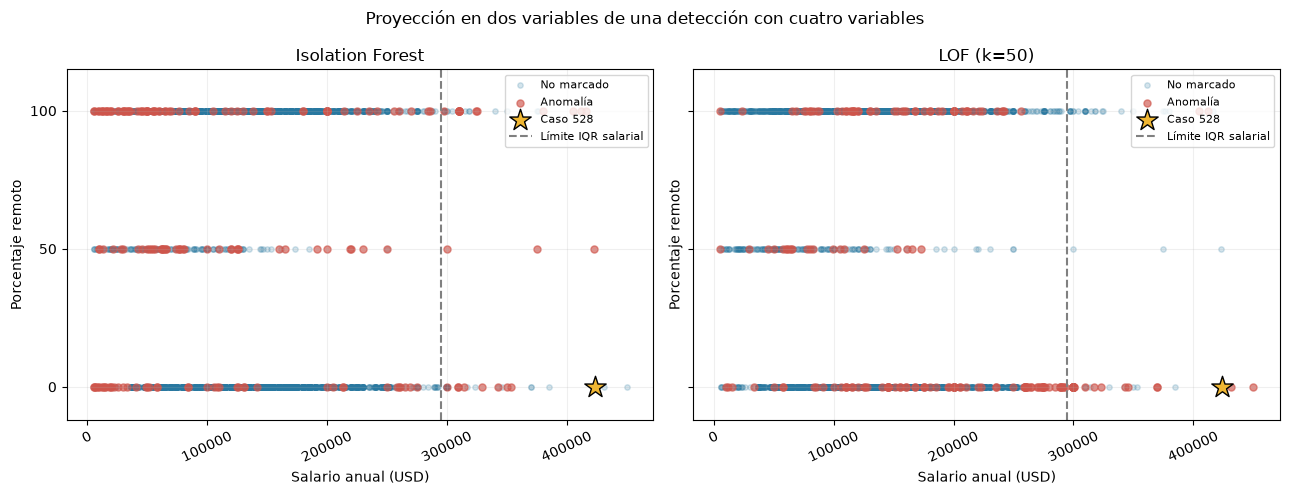

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, col, titulo in zip(axes, ['anomalia_IF', 'anomalia_LOF'], ['Isolation Forest', 'LOF (k=50)']):
    marcadas = resultado[col]
    ax.scatter(df.loc[~marcadas, 'salary_in_usd'], df.loc[~marcadas, 'remote_ratio'],
               s=15, alpha=.20, color='#2878a0', label='No marcado')
    ax.scatter(df.loc[marcadas, 'salary_in_usd'], df.loc[marcadas, 'remote_ratio'],
               s=26, alpha=.65, color='#cf554b', label='Anomalía')
    ax.scatter(caso.salary_in_usd, caso.remote_ratio, marker='*', s=260,
               color='#efb633', edgecolor='black', label=f'Caso {caso_id}', zorder=5)
    ax.axvline(superior, color='gray', linestyle='--', label='Límite IQR salarial')
    ax.set(title=titulo, xlabel='Salario anual (USD)', ylabel='Porcentaje remoto', yticks=[0, 50, 100], ylim=(-12, 115))
    ax.ticklabel_format(axis='x', style='plain')
    ax.tick_params(axis='x', labelrotation=25)
    ax.legend(fontsize=8, loc='upper right')
fig.suptitle('Proyección en dos variables de una detección con cuatro variables')
plt.tight_layout()
plt.show()

### Sensibilidad a la vecindad y decisión sobre el registro
Al revisar los vecinos de la fila 528, encontré salarios entre **260.000 y 450.000 USD**; el vecino más próximo tiene experiencia SE, trabajo presencial, empresa L y un salario de **350.000 USD**. Por eso considero que el caso es extremo en el conjunto, pero tiene un entorno de salarios altos. Su factor LOF de **2,4553** indica menor densidad relativa, aunque queda por debajo del corte de **2,5556**. Esto respalda mi interpretación del desacuerdo sin afirmar que LOF lo considere completamente típico.

Revisé k = 75 y 100 manteniendo el resto del preprocesamiento y la contaminación. No usé este control para elegir retrospectivamente la etiqueta que prefiero; lo uso para mostrar qué tan estable es la decisión del caso. No hay etiquetas verdaderas de anomalía con las que pueda calcular precisión o recall.

En los resultados, el caso cambia de no marcado con k=50 a marcado con k=75 y k=100. Interpreto que **su etiqueta LOF no es estable frente a estos cambios de vecindad**; no describiría el desacuerdo con Isolation Forest como una propiedad permanente del registro. La coincidencia global de 26 casos sobre una unión de 344 (Jaccard ≈ 0,076) también me indica que las listas priorizan perfiles distintos, pero no me permite decidir cuál método es más preciso sin etiquetas verificadas.

In [10]:
sens_lof = []
for k in [50, 75, 100]:
    modelo = lof if k == K else LocalOutlierFactor(n_neighbors=k, contamination=0.05).fit(Z)
    factores = -modelo.negative_outlier_factor_
    umbral = -modelo.offset_
    sens_lof.append({'k': k, 'umbral LOF': umbral, 'factor del caso': factores[posicion_caso],
                     'marca el caso': bool(factores[posicion_caso] > umbral),
                     'total marcados': int((factores > umbral).sum())})
display(pd.DataFrame(sens_lof))
display(Markdown('Con este control observo que la etiqueta puede depender de la escala de vecindad. '
    'Por eso no elimino el registro automáticamente: revisaría el cargo, el contrato, la moneda, '
    'la conversión y si el monto incluye componentes extraordinarios. Si verificara un error, lo corregiría '
    'con la fuente; si fuera un salario real dentro de la población estudiada, lo conservaría. '
    'No confundo una observación poco frecuente con un dato inválido.'))

,k,umbral LOF,factor del caso,marca el caso,total marcados
0,50,2.5556,2.4553,False,187
1,75,2.7281,2.9516,True,183
2,100,3.3902,3.7493,True,188


Con este control observo que la etiqueta puede depender de la escala de vecindad. Por eso no elimino el registro automáticamente: revisaría el cargo, el contrato, la moneda, la conversión y si el monto incluye componentes extraordinarios. Si verificara un error, lo corregiría con la fuente; si fuera un salario real dentro de la población estudiada, lo conservaría. No confundo una observación poco frecuente con un dato inválido.

## 7. Conclusiones
- **Calidad:** pude verificar completitud, formato y dominios de las cuatro variables; la alerta pendiente está en las repeticiones exactas. No tengo evidencia suficiente para tratarlas todas como errores ni para confirmar la exactitud de cada salario.
- **Drift:** obtuve PSI de **0,8701 en salario**, **0,7417 en experiencia**, **1,1914 en porcentaje remoto** y **2,1981 en tamaño de empresa**. Los cuatro superan el umbral de 0,25 y mantienen la alerta al quitar duplicados. Distingo cambios de entradas y del target; no deduzco concept drift ni pérdida de desempeño solamente a partir de PSI.
- **Modelo de la Actividad 1:** elegiría reentrenar el bosque sin leakage con información reciente y validación temporal. La partición aleatoria de la actividad anterior no equivale a una evaluación prospectiva.
- **Anomalías:** obtuve **183 registros marcados por Isolation Forest**, **187 por LOF** y **26 coincidencias**. La fila 528 tiene un salario de **423.834 USD**, superior al límite IQR de **295.000 USD**; por eso la identifiqué como un outlier univariado salarial. Isolation Forest la marca y LOF con k=50 no; con k=75 y k=100, LOF también la marca. También revisé cómo los perfiles repetidos y el número de vecinos afectan a LOF.
- **Límites:** mis umbrales y la contaminación son decisiones exploratorias. No tengo etiquetas de anomalía, validación externa de salarios ni evidencia para atribuir los cambios a una causa concreta. Los datos actuales son muchos más que los de referencia y pueden representar una población de empleos distinta.


